### Concepts Covered

**HuberMetric**:	Custom metric for regression-style error evaluation

**AddGaussianNoise**:	Adds Gaussian noise during training (data augmentation)

**SimpleLayerNormalization**:	Custom implementation of layer normalization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load and Normalize Data

In [2]:
# Load & normalize Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Custom Huber Metric

In [3]:
# Custom Huber Metric
class HuberMetric(keras.metrics.Metric):
    def __init__(self, delta=1.0, name="huber_metric", **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        error = tf.abs(y_true - y_pred)
        is_small_error = error <= self.delta
        squared_loss = tf.square(error) / 2
        linear_loss = self.delta * (error - self.delta / 2)
        loss = tf.where(is_small_error, squared_loss, linear_loss)
        self.total.assign_add(tf.reduce_sum(loss))
        self.count.assign_add(tf.cast(tf.size(loss), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_states(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

# Add Gaussian Noise

In [4]:
# Add Gaussian Noise
class AddGaussianNoise(layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=False):
        if training:
            noise = tf.random.normal(tf.shape(inputs), stddev=self.stddev)
            return inputs + noise
        return inputs

# Layer Normalization

In [5]:
# Layer Normalization
class SimpleLayerNormalization(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=input_shape[-1:], initializer="ones", trainable=True)
        self.beta = self.add_weight(shape=input_shape[-1:], initializer="zeros", trainable=True)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        norm_inputs = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * norm_inputs + self.beta

# Build Model

In [6]:
# Build Model
def build_model():
    return keras.models.Sequential([
        keras.Input(shape=(28, 28, 1)),
        AddGaussianNoise(0.2),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        SimpleLayerNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# Convert labels

In [7]:
# Convert labels to one-hot for HuberMetric
y_train_oh = tf.one_hot(y_train, depth=10)
y_test_oh = tf.one_hot(y_test, depth=10)

# Compile and Train

In [8]:
# Compile and Train
model = build_model()
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy", HuberMetric()])
history = model.fit(X_train, y_train_oh, epochs=5, batch_size=64, validation_data=(X_test, y_test_oh), verbose=2)


Epoch 1/5
938/938 - 47s - 50ms/step - accuracy: 0.8210 - huber_metric: 0.0125 - loss: 0.4913 - val_accuracy: 0.8471 - val_huber_metric: 0.0108 - val_loss: 0.4140
Epoch 2/5
938/938 - 85s - 90ms/step - accuracy: 0.8638 - huber_metric: 0.0096 - loss: 0.3663 - val_accuracy: 0.8612 - val_huber_metric: 0.0098 - val_loss: 0.3796
Epoch 3/5
938/938 - 78s - 83ms/step - accuracy: 0.8790 - huber_metric: 0.0087 - loss: 0.3256 - val_accuracy: 0.8597 - val_huber_metric: 0.0100 - val_loss: 0.3888
Epoch 4/5
938/938 - 82s - 88ms/step - accuracy: 0.8848 - huber_metric: 0.0082 - loss: 0.3044 - val_accuracy: 0.8731 - val_huber_metric: 0.0089 - val_loss: 0.3330
Epoch 5/5
938/938 - 42s - 45ms/step - accuracy: 0.8908 - huber_metric: 0.0078 - loss: 0.2891 - val_accuracy: 0.8749 - val_huber_metric: 0.0089 - val_loss: 0.3374


# Plot Accuracy & Huber Metric

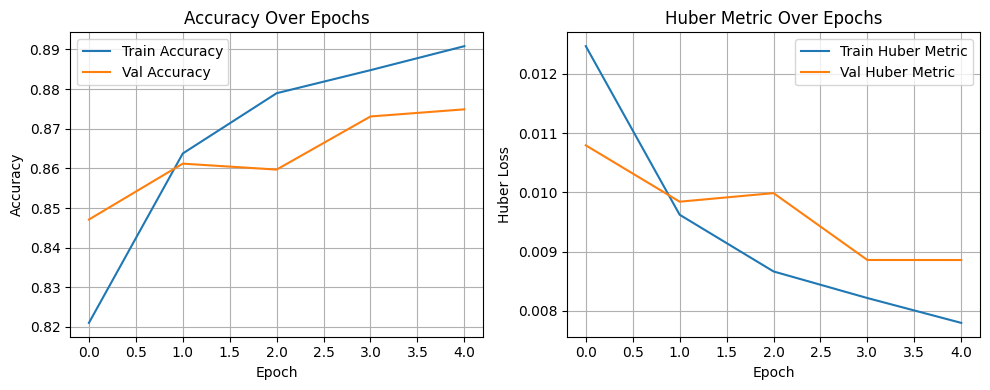

In [9]:
# Plot Accuracy & Huber Metric
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['huber_metric'], label='Train Huber Metric')
plt.plot(history.history['val_huber_metric'], label='Val Huber Metric')
plt.title("Huber Metric Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()